In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import os
import requests
import json
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

In [4]:
!conda env export

name: base
channels:
  - defaults
dependencies:
  - _anaconda_depends=2025.12=py313_mkl_0
  - aiobotocore=2.25.0=py313haa95532_0
  - aiodns=3.5.0=py313haa95532_1
  - aiohappyeyeballs=2.6.1=py313haa95532_0
  - aiohttp=3.13.2=py313h02ab6af_0
  - aioitertools=0.12.0=py313haa95532_0
  - aiosignal=1.4.0=py313haa95532_0
  - alabaster=0.7.16=py313haa95532_0
  - altair=5.5.0=py313haa95532_0
  - anaconda-anon-usage=0.7.5=pyhb46e38b_100
  - anaconda-auth=0.12.0=py313haa95532_0
  - anaconda-catalogs=0.2.0=py313haa95532_3
  - anaconda-cli-base=0.7.0=py313haa95532_0
  - anaconda-client=1.14.0=py313haa95532_0
  - anaconda-navigator=2.7.2=py313haa95532_0
  - anaconda-project=0.11.1=py313haa95532_1
  - anaconda_powershell_prompt=1.1.0=haa95532_1
  - anaconda_prompt=1.1.0=haa95532_1
  - annotated-types=0.6.0=py313haa95532_1
  - anyio=4.10.0=py313haa95532_0
  - aom=3.12.1=h00a0c3c_0
  - appdirs=1.4.4=pyhd3eb1b0_0
  - archspec=0.2.5=pyhd3eb1b0_0
  - argon2-cffi=21.3.0=pyhd3eb1b0_0
  - argon2-cffi-binding

In [5]:
# Read in data
maf = pd.read_csv("cohortMAF.2026-09-04.maf", sep="\t", comment="#")

In [6]:
maf["Tumor_Sample_Barcode"].unique()

array(['TCGA-GV-A3QG-01A-11D-A21Z-08', 'TCGA-FD-A5C1-01A-11D-A289-08',
       'TCGA-DK-A3IT-01A-31D-A20D-08', 'TCGA-DK-A6B2-01A-11D-A30E-08',
       'TCGA-K4-AAQO-01A-11D-A38G-08', 'TCGA-GC-A3YS-01A-11D-A23M-08',
       'TCGA-DK-A3IQ-01A-31D-A20D-08', 'TCGA-GV-A40E-01A-12D-A23M-08',
       'TCGA-FD-A3SQ-01A-21D-A22Z-08', 'TCGA-DK-A3IS-01A-21D-A21A-08',
       'TCGA-FD-A43P-01A-31D-A23U-08', 'TCGA-K4-A3WS-01A-11D-A22Z-08',
       'TCGA-FD-A6TC-01A-21D-A339-08', 'TCGA-FD-A6TI-01A-11D-A32B-08',
       'TCGA-FD-A6TH-01A-11D-A32B-08', 'TCGA-ZF-AA51-01A-21D-A391-08',
       'TCGA-UY-A9PA-01A-11D-A38G-08', 'TCGA-4Z-AA82-01A-11D-A391-08',
       'TCGA-GV-A3JW-01A-11D-A20D-08', 'TCGA-4Z-AA7Y-01A-11D-A391-08',
       'TCGA-FD-A43N-01A-11D-A23U-08', 'TCGA-FD-A3B3-01A-12D-A202-08',
       'TCGA-FD-A3B6-01A-21D-A20D-08', 'TCGA-BT-A20T-01A-11D-A14W-08',
       'TCGA-FD-A3SM-01A-11D-A22Z-08', 'TCGA-BT-A20W-01A-21D-A14W-08',
       'TCGA-GU-A764-01A-11D-A34U-08', 'TCGA-XF-AAMH-01A-11D-A42E-08',
      

In [7]:
# Get mutation counts
mutation_counts = maf.groupby("Tumor_Sample_Barcode").size()

In [8]:
# Calculate basic mutation count statistics
mutation_counts.describe()

count     414.000000
mean      282.736715
std       326.671104
min         1.000000
25%       106.000000
50%       193.000000
75%       351.000000
max      4296.000000
dtype: float64

In [9]:
# Get SNP counts
snp_counts = (
    maf[maf["Variant_Type"] == "SNP"]
    .groupby("Tumor_Sample_Barcode")
    .size()
)
# Calculate basic SNP count statistics
snp_counts.describe()

count     414.000000
mean      276.248792
std       324.152751
min         1.000000
25%       100.250000
50%       190.500000
75%       344.000000
max      4282.000000
dtype: float64

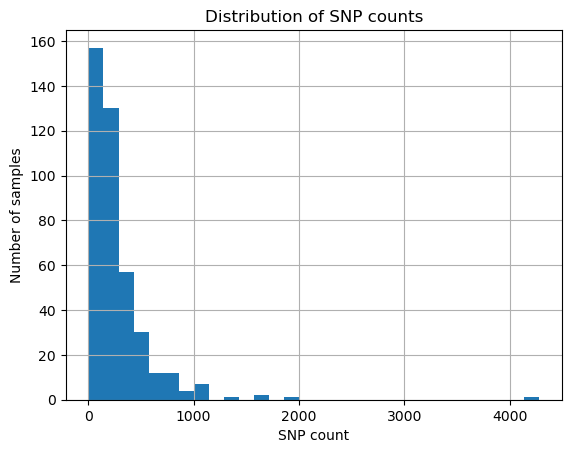

In [10]:
# Plot SNP counts
snp_counts.hist(bins=30)

plt.xlabel("SNP count")
plt.ylabel("Number of samples")
plt.title("Distribution of SNP counts")

plt.savefig("snp_counts.pdf", bbox_inches="tight")
plt.show()
plt.close()

In [11]:
# Observe overview of mutations
print(maf.shape)
print(maf["Tumor_Sample_Barcode"].nunique())
print(maf["Variant_Type"].value_counts())
print(maf["Variant_Classification"].value_counts())

(117053, 140)
414
Variant_Type
SNP    114367
DEL      2010
INS       674
ONP         1
TNP         1
Name: count, dtype: int64
Variant_Classification
Missense_Mutation         73598
Silent                    28467
Nonsense_Mutation          7188
Splice_Site                1561
Frame_Shift_Del            1474
Intron                     1176
Splice_Region               658
RNA                         653
Frame_Shift_Ins             591
In_Frame_Del                324
5'UTR                       299
5'Flank                     297
3'UTR                       289
3'Flank                     174
Nonstop_Mutation            131
Translation_Start_Site      129
In_Frame_Ins                 42
IGR                           2
Name: count, dtype: int64


In [12]:
# Load NMF output once
with pd.HDFStore("nmf_output.h5", "r") as store:
    # Aggregate results
    aggr = store["aggr"]

    # Load W matrices from all runs
    Ws = {
        i: store[f"/run{i}/W"].values
        for i in range(10)
    }

    # Load final H and W matrices
    H = store["/H"]
    W = store["/W"]


# Make sure relevant columns are numeric
aggr["K"] = pd.to_numeric(aggr["K"])
aggr["obj"] = pd.to_numeric(aggr["obj"])


# Look at objective values by number of signatures
print("Objective values by K:")
print(aggr.groupby("K")["obj"].agg(
    ["min", "max", "mean", "std"]
))


# Check dimensions of W matrices from each run
print("\nW matrix dimensions:")
for i, W_run in Ws.items():
    print(f"run{i}: {W_run.shape}")


# Compare run 0 against every other run
for i in range(1, 10):
    sim = cosine_similarity(Ws[0].T, Ws[i].T)

    print(f"\nRun 0 vs Run {i}")
    print(np.round(sim, 3))


# Inspect final H matrix
print("\nH matrix:")
print(H.shape)
print(H.head())
print(H.index[:5])
print(H.columns)


# Inspect final W matrix
print("\nW matrix:")
print(W.shape)
print(W.head())
print(W.columns)

Objective values by K:
             min           max           mean       std
K                                                      
5 -211164.390625 -211151.46875 -211160.746875  4.779019

W matrix dimensions:
run0: (96, 8)
run1: (96, 8)
run2: (96, 8)
run3: (96, 8)
run4: (96, 8)
run5: (96, 8)
run6: (96, 8)
run7: (96, 8)
run8: (96, 8)
run9: (96, 8)

Run 0 vs Run 1
[[0.12  0.599 0.261 0.126 1.    0.733 0.427 0.161]
 [0.997 0.114 0.136 0.457 0.123 0.331 0.705 0.783]
 [0.158 0.198 1.    0.3   0.262 0.6   0.382 0.224]
 [0.117 1.    0.198 0.075 0.597 0.778 0.396 0.303]
 [0.336 0.066 0.267 0.996 0.116 0.474 0.471 0.23 ]
 [0.322 0.762 0.573 0.534 0.72  0.998 0.647 0.417]
 [0.789 0.293 0.294 0.51  0.133 0.486 0.901 0.874]
 [0.809 0.293 0.215 0.256 0.156 0.41  0.737 0.999]]

Run 0 vs Run 2
[[0.13  0.119 0.599 0.263 1.    0.735 0.381 0.161]
 [0.46  0.996 0.114 0.136 0.123 0.331 0.69  0.783]
 [0.307 0.173 0.199 1.    0.263 0.6   0.389 0.222]
 [0.077 0.118 1.    0.199 0.597 0.78  0.421 0.303]
 [

In [13]:
# Start of stability analysis - summary of how reproducible signatures are across runs
stability = []
for i in range(10):
    for j in range(i + 1, 10):
        sim = cosine_similarity(Ws[i].T, Ws[j].T)

        # For each signature in run i, find its best match in run j
        best_matches = sim.max(axis=1)

        stability.extend(best_matches)

print("Mean cosine similarity:", np.mean(stability))
print("Median cosine similarity:", np.median(stability))
print("Minimum cosine similarity:", np.min(stability))

Mean cosine similarity: 0.9850461749932115
Median cosine similarity: 0.9998430011063681
Minimum cosine similarity: 0.7371202453312576


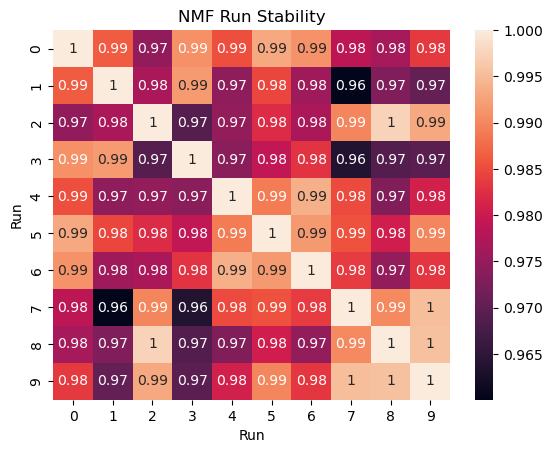

(414, 8)
                              S1-Signature 5  S2-Signature 13  \
sample                                                          
TCGA-2F-A9KO-01A-11D-A38G-08       40.483849       499.433716   
TCGA-2F-A9KP-01A-11D-A38G-08       29.668684        43.963127   
TCGA-2F-A9KQ-01A-11D-A38G-08       24.413601        13.296408   
TCGA-2F-A9KR-01A-11D-A38G-08       30.218742       122.111908   
TCGA-2F-A9KT-01A-11D-A38G-08       10.548070       289.050934   

                              S3-Signature 10  S4-Signature 1  S5-Signature 2  \
sample                                                                          
TCGA-2F-A9KO-01A-11D-A38G-08     2.100546e-42        6.798069       48.668167   
TCGA-2F-A9KP-01A-11D-A38G-08     7.356817e-43       29.458412       30.032536   
TCGA-2F-A9KQ-01A-11D-A38G-08     3.017730e+00       17.201454        7.937285   
TCGA-2F-A9KR-01A-11D-A38G-08     2.512373e+00       14.910617       70.804741   
TCGA-2F-A9KT-01A-11D-A38G-08     5.292986e+00    

In [14]:
# Stability heatmap
stability = np.ones((10, 10))

for i in range(10):
    for j in range(i + 1, 10):
        similarity = cosine_similarity(Ws[i].T, Ws[j].T)

        row_ind, col_ind = linear_sum_assignment(1 - similarity)
        matched_scores = similarity[row_ind, col_ind]

        mean_similarity = matched_scores.mean()

        stability[i, j] = mean_similarity
        stability[j, i] = mean_similarity


sns.heatmap(
    stability,
    xticklabels=range(10),
    yticklabels=range(10),
    annot=True
)

plt.xlabel("Run")
plt.ylabel("Run")
plt.title("NMF Run Stability")
plt.savefig("similarity.pdf")
plt.show()


print(H.shape)
print(H.head())
print(H.index[:5])
print(H.columns)

print(W.shape)
print(W.head())
print(W.columns)

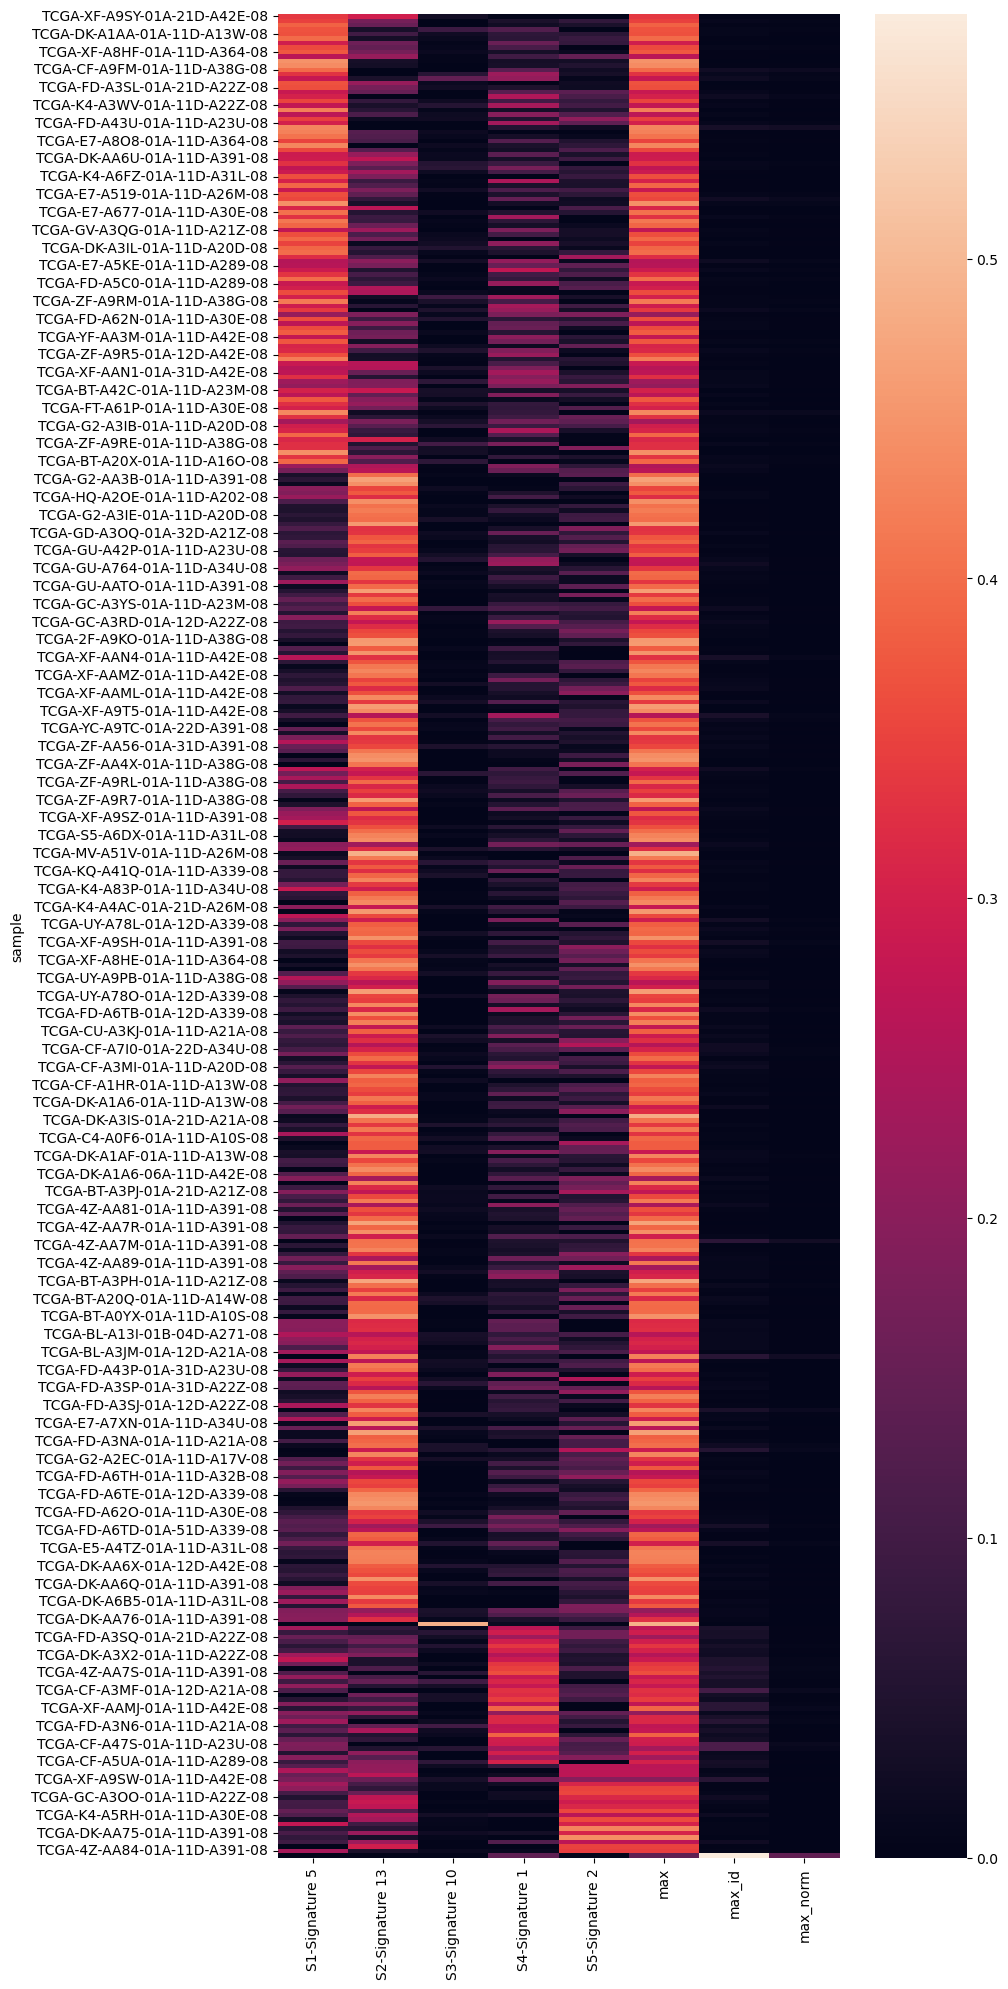

In [15]:
# Plot signature proportions
signature_cols = H.columns.tolist()
H_sig = H[signature_cols]
H_relative = H_sig.div(H_sig.sum(axis=1), axis=0)
top_sig = H_relative.idxmax(axis=1)
H_sorted = H_relative.loc[top_sig.sort_values().index]
plt.figure(figsize=(10, 20))
sns.heatmap(H_sorted)
plt.tight_layout()
plt.savefig("signature_proportions.pdf", bbox_inches="tight")
plt.show()

In [16]:
# Find common tumor samples
common_samples = H_sig.index.intersection(snp_counts.index)
H_sig_common = H_sig.loc[common_samples]
snp_counts_common = snp_counts.loc[common_samples]
H_sig_common.index.equals(snp_counts_common.index)

True

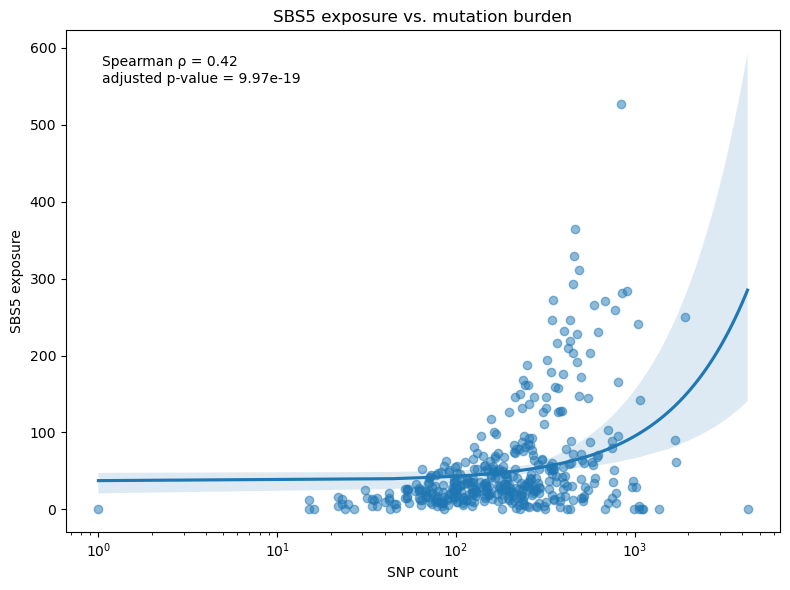

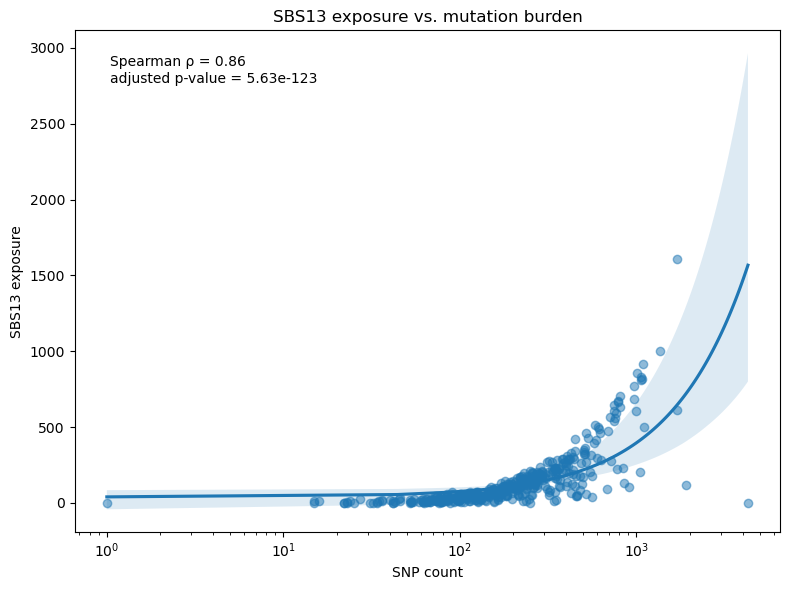

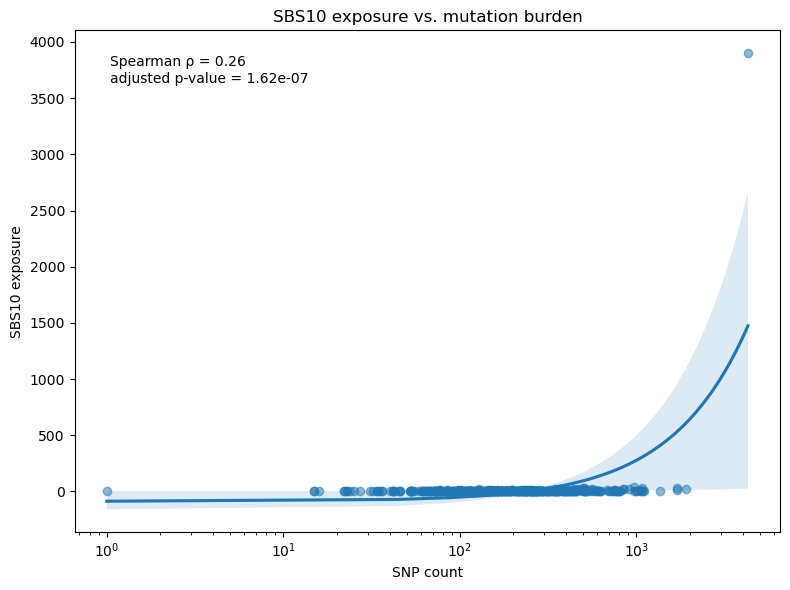

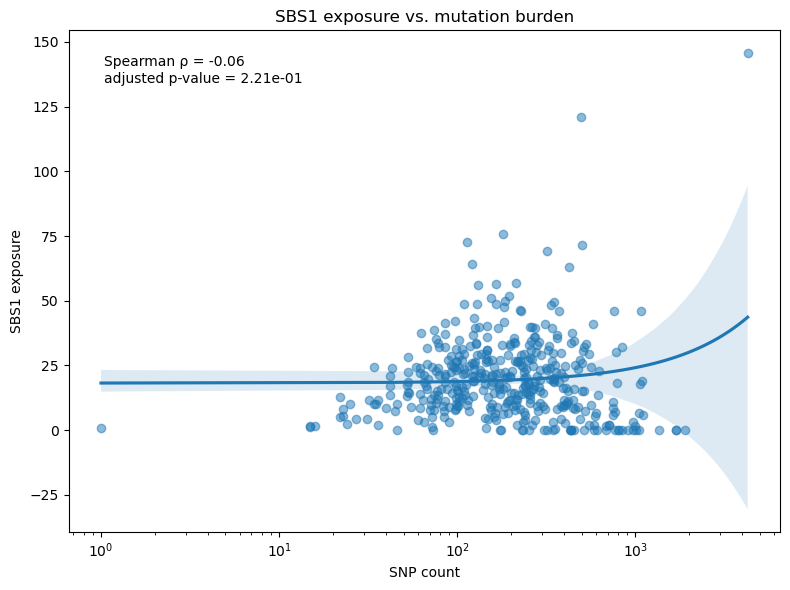

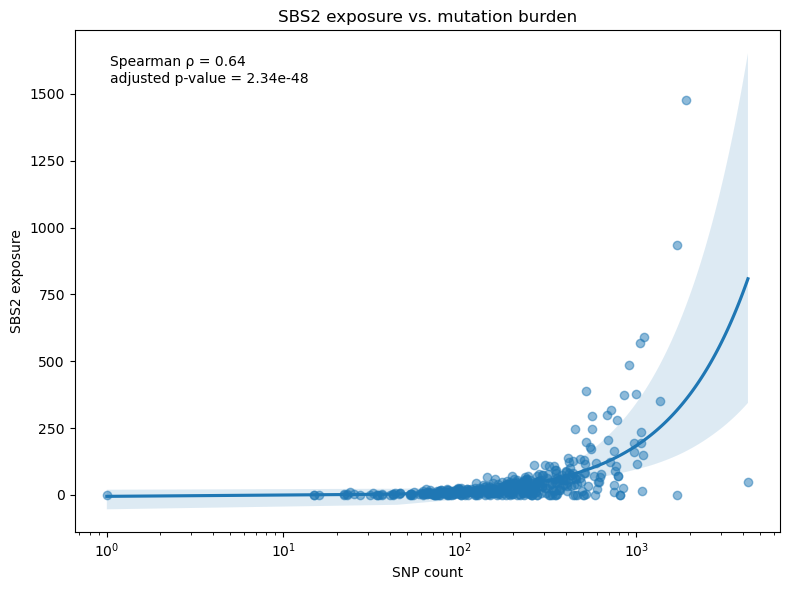

In [17]:
# Find correlations beween signatures and mutation burden
correlations = {}
for signature in H_sig_common.columns:
    rho, pvalue = spearmanr(snp_counts_common, H_sig_common[signature])
    correlations[signature] = {"rho": rho, "pvalue": pvalue}

pvalues = [correlations[signature]["pvalue"] for signature in correlations]
multipletests_result = multipletests(pvalues, method="fdr_bh")

for signature, pvalue_adj in zip(correlations, multipletests_result[1]):
    correlations[signature]["pvalue_adj"] = pvalue_adj


def plot_signature_correlation(signature, display_name, filename):
    rho = correlations[signature]["rho"]
    pvalue_adj = correlations[signature]["pvalue_adj"]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.regplot(
        x=snp_counts_common,
        y=H_sig_common[signature],
        scatter_kws={"alpha": 0.5},
        ax=ax
    )
    ax.set_xscale("log")
    ax.set_xlabel("SNP count")
    ax.set_ylabel(f"{display_name} exposure")
    ax.set_title(f"{display_name} exposure vs. mutation burden")
    ax.text(
        0.05, 0.95,
        f"Spearman \u03c1 = {rho:.2f}\nadjusted p-value = {pvalue_adj:.2e}",
        transform=ax.transAxes,
        verticalalignment="top"
    )
    fig.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.show()
    plt.close(fig)


signatures = {
    "S1-Signature 5": "SBS5",
    "S2-Signature 13": "SBS13",
    "S3-Signature 10": "SBS10",
    "S4-Signature 1": "SBS1",
    "S5-Signature 2": "SBS2"
}

for signature, display_name in signatures.items():
    filename = f"{display_name}_mutation_burden.pdf"
    plot_signature_correlation(signature, display_name, filename)


In [18]:
# The next step was to download the counts data. 
# After downloading the counts data from TCGA, the next two functions handle the counts matrices into a workable format
def process_one_file(folder):
    tsv_file = next(
    f for f in os.listdir(folder)
    if f.endswith(".tsv")
    )

    filepath = os.path.join(folder, tsv_file)

    test_df = pd.read_csv(
    filepath,
    sep="\t",
    comment="#"
    )

    test_df = test_df[
    ~test_df["gene_id"].isin([
        "N_unmapped",
        "N_multimapping",
        "N_noFeature",
        "N_ambiguous"
    ])
    ].reset_index(drop=True)

    test_df["gene_id"] = test_df["gene_id"].str.split(".").str[0]
    output_df = test_df[["gene_id", "gene_name", "gene_type", "unstranded"]]
    return output_df

def process_multiple_files(folder_list):
    all_dfs = {}

    for folder in folder_list:
        file_id = os.path.basename(os.path.normpath(folder))
        df = process_one_file(folder)
        all_dfs[file_id] = df
    
    return all_dfs

folder_list = [
    os.path.join("./Counts", folder)
    for folder in os.listdir("./Counts")
]

all_dfs = process_multiple_files(folder_list)

In [19]:
# Downloaded the metadata to match sample barcodes to counts data, and then processed the metadata file
def get_sample_mapping(manifest):
    records = []

    for file_id in manifest["id"]:
        url = f"https://api.gdc.cancer.gov/files/{file_id}"

        params = {
            "expand": "cases.samples.portions.analytes"
        }

        response = requests.get(url, params=params)
        response.raise_for_status()

        data = response.json()["data"]

        for case in data.get("cases", []):
            for sample in case.get("samples", []):
                for portion in sample.get("portions", []):
                    for analyte in portion.get("analytes", []):

                        analyte_barcode = analyte.get("submitter_id")

                        if analyte_barcode:
                            sample_barcode = "-".join(
                                analyte_barcode.split("-")[:4]
                            )
                        else:
                            sample_barcode = None

                        records.append({
                            "file_id": file_id,
                            "file_name": data.get("file_name"),
                            "sample_barcode": sample_barcode,
                            "sample_type": sample.get("sample_type"),
                            "tissue_type": sample.get("tissue_type"),
                            "analyte_barcode": analyte_barcode,
                            "analyte_id": analyte.get("analyte_id"),
                            "analyte_type": analyte.get("analyte_type"),
                        })

    return pd.DataFrame(records)

In [20]:
manifest = pd.read_csv("gdc_manifest.2026-09-18.195738.txt", sep="\t")

In [21]:
sample_mapping = get_sample_mapping(manifest)

In [22]:
# Duplicate analyte processing
sample_mapping["analyte_barcode"].value_counts().loc[
    lambda x: x > 1
]

analyte_barcode
TCGA-BL-A0C8-01A-11R    2
TCGA-BL-A13J-01A-11R    2
TCGA-BL-A13I-01A-11R    2
Name: count, dtype: int64

In [23]:
# Duplicate analyte processing
duplicate_analytes = (
    sample_mapping["analyte_barcode"]
    .value_counts()
    .loc[lambda x: x > 1]
)

duplicate_files = sample_mapping[
    sample_mapping["analyte_barcode"].isin(duplicate_analytes.index)
]

duplicate_files[
    [
        "file_id",
        "file_name",
        "sample_barcode",
        "analyte_barcode"
    ]
]

,file_id,file_name,sample_barcode,analyte_barcode
50,4760b098-978b-4f2f-9bff-127d8edb48de,7cd8c835-cbce-4aa1-84d0-3ea7d3112630.rna_seq.a...,TCGA-BL-A13J-01A,TCGA-BL-A13J-01A-11R
105,dd578d7c-9577-4bda-a1b1-1fd063206537,49432779-e2b3-4e36-b1a9-88c7c45854ff.rna_seq.a...,TCGA-BL-A0C8-01A,TCGA-BL-A0C8-01A-11R
106,49a6de74-9360-4347-a594-d64d5aa5ce9e,e1e79392-73f2-4a23-961e-19dc6a315b22.rna_seq.a...,TCGA-BL-A0C8-01A,TCGA-BL-A0C8-01A-11R
166,0d50ca90-4dfc-4dc8-b353-0d2af65649d6,829d07d7-8a03-4350-8999-4ffd493f6218.rna_seq.a...,TCGA-BL-A13J-01A,TCGA-BL-A13J-01A-11R
350,f36b3cb3-b632-43c6-a6e3-c325c9e7026f,083c5185-07a4-4d45-a852-aaadfe41dcef.rna_seq.a...,TCGA-BL-A13I-01A,TCGA-BL-A13I-01A-11R
410,3c5d447f-7b0a-48db-a155-189f73e7f7da,83b37bd1-fd81-4ebc-a513-449cbd1710e8.rna_seq.a...,TCGA-BL-A13I-01A,TCGA-BL-A13I-01A-11R


In [24]:
# Duplicate analyte processing
duplicate_files = {
    "TCGA-BL-A0C8-01A": "49a6de74-9360-4347-a594-d64d5aa5ce9e",
    "TCGA-BL-A13J-01A": "0d50ca90-4dfc-4dc8-b353-0d2af65649d6",
    "TCGA-BL-A13I-01A": "3c5d447f-7b0a-48db-a155-189f73e7f7da"
}

In [25]:
# Remove redundant files associated with duplicate analytes
sample_mapping_filtered = sample_mapping[
    ~sample_mapping["file_id"].isin(duplicate_files.values())
].copy()

In [26]:
# Map the sample barcode to the expression data
def map_samples_to_counts(expression_data, sample_mapping):
    sample_counts = {}

    for _, row in sample_mapping.iterrows():
        file_id = row["file_id"]
        sample_barcode = row["sample_barcode"]

        if file_id not in expression_data:
            raise ValueError(f"{file_id} not found in expression_data")

        if sample_barcode in sample_counts:
            raise ValueError(
                f"Duplicate sample barcode found: {sample_barcode}"
            )

        sample_counts[sample_barcode] = expression_data[file_id]

    return sample_counts

In [27]:
sample_counts = map_samples_to_counts(
    all_dfs,
    sample_mapping_filtered
)

In [28]:
# Concatenate the sample counts
def build_expression_matrix(sample_counts):
    expression_matrix = pd.concat(
        {
            sample_barcode: df.set_index("gene_id")["unstranded"]
            for sample_barcode, df in sample_counts.items()
        },
        axis=1
    )

    expression_matrix.columns.name = "sample_barcode"

    return expression_matrix

In [29]:
expression_matrix = build_expression_matrix(sample_counts)

In [30]:
# Standardize signature sample IDs to the same 4-part TCGA barcode
H_normalized = H.copy()

H_normalized["sample_barcode"] = (
    H_normalized.index
    .astype(str)
    .str.split("-")
    .str[:4]
    .str.join("-")
)

# Check whether normalization created duplicate sample IDs
print("H rows:", len(H_normalized))
print("Unique normalized samples:", H_normalized["sample_barcode"].nunique())

H rows: 414
Unique normalized samples: 411


In [31]:
common_samples = (
    expression_matrix.columns
    .intersection(H_normalized["sample_barcode"])
)

print("Matched samples:", len(common_samples))

Matched samples: 404


In [37]:
expression_matched = expression_matrix[common_samples].copy()

signature_matched = (
    H_normalized[
        H_normalized["sample_barcode"].isin(common_samples)
    ]
    .drop_duplicates(
        subset="sample_barcode",
        keep="first"
    )
    .set_index("sample_barcode")
)

# Align signature samples to expression sample order
signature_matched = signature_matched.loc[
    expression_matched.columns
]

# Verify alignment
assert expression_matched.columns.equals(
    signature_matched.index
)

print("Samples aligned:", expression_matched.columns.equals(signature_matched.index))
print("Expression samples:", expression_matched.shape[1])
print("Signature samples:", signature_matched.shape[0])

Samples aligned: True
Expression samples: 404
Signature samples: 404


In [34]:
duplicate_signature_samples = (
    H_normalized["sample_barcode"]
    .value_counts()
    .loc[lambda x: x > 1]
)

print(duplicate_signature_samples)

sample_barcode
TCGA-BL-A13J-01A    2
TCGA-BL-A13I-01A    2
TCGA-BL-A0C8-01A    2
Name: count, dtype: int64


In [35]:
duplicate_ids = duplicate_signature_samples.index

H_normalized[
    H_normalized["sample_barcode"].isin(duplicate_ids)
]

,S1-Signature 5,S2-Signature 13,S3-Signature 10,S4-Signature 1,S5-Signature 2,max,max_id,max_norm,sample_barcode
sample,,,,,,,,,
TCGA-BL-A0C8-01A-11D-A10S-08,25.835154,54.100395,5.109708e+00,33.191364,7.829337e+00,54.100395,2,0.429144,TCGA-BL-A0C8-01A
TCGA-BL-A0C8-01A-11D-A271-08,21.148083,55.727215,8.560295e-01,36.912678,6.564684e+00,55.727215,2,0.459763,TCGA-BL-A0C8-01A
TCGA-BL-A13I-01A-11D-A13W-08,30.111788,47.694359,4.070940e+00,12.341934,8.520447e+00,47.694359,2,0.464226,TCGA-BL-A13I-01A
TCGA-BL-A13I-01A-11D-A271-08,31.759268,46.045174,4.967698e+00,16.771000,4.063409e+00,46.045174,2,0.444423,TCGA-BL-A13I-01A
TCGA-BL-A13J-01A-11D-A10S-08,35.543060,59.595963,5.254869e-43,25.372814,5.907112e-37,59.595963,2,0.494524,TCGA-BL-A13J-01A
TCGA-BL-A13J-01A-11D-A271-08,32.414555,52.186192,9.201853e-01,22.121553,1.952009e-42,52.186192,2,0.484810,TCGA-BL-A13J-01A


In [38]:
# Filter low expressed genes
# Total raw counts per sample
library_sizes = expression_matched.sum(axis=0)

# Counts per million
cpm = expression_matched.div(library_sizes, axis=1) * 1e6

min_samples = int(np.ceil(0.20 * cpm.shape[1]))

expressed = (
    (cpm >= 1)
    .sum(axis=1)
    >= min_samples
)

cpm_filtered = cpm.loc[expressed].copy()

print("Genes before filtering:", cpm.shape[0])
print("Genes after filtering:", cpm_filtered.shape[0])
print("Minimum samples required:", min_samples)

log_cpm = np.log2(cpm_filtered + 1)

print("Final expression matrix:", log_cpm.shape)
print("Final signature matrix:", signature_matched.shape)
print(
    "Samples aligned:",
    log_cpm.columns.equals(signature_matched.index)
)



Genes before filtering: 60660
Genes after filtering: 17088
Minimum samples required: 81
Final expression matrix: (17088, 404)
Final signature matrix: (404, 8)
Samples aligned: True


In [39]:
# Calculate correlation between expression and signatures, apply multiple testing correction
results = []

for signature in signature_matched.columns:
    signature_values = signature_matched[signature]

    for gene in log_cpm.index:
        expression_values = log_cpm.loc[gene]

        rho, p = spearmanr(
            expression_values,
            signature_values
        )

        results.append({
            "gene_id": gene,
            "signature": signature,
            "rho": rho,
            "p_value": p
        })

results = pd.DataFrame(results)

print(results.shape)
print(results.head())

# Benjamini-Hochberg FDR correction
results["FDR"] = multipletests(
    results["p_value"],
    method="fdr_bh"
)[1]

print(results.head())

(136704, 4)
           gene_id       signature       rho       p_value
0  ENSG00000000003  S1-Signature 5  0.006088  9.029016e-01
1  ENSG00000000419  S1-Signature 5  0.143812  3.771012e-03
2  ENSG00000000457  S1-Signature 5  0.032671  5.125840e-01
3  ENSG00000000460  S1-Signature 5  0.272904  2.482879e-08
4  ENSG00000000938  S1-Signature 5 -0.190164  1.202786e-04
           gene_id       signature       rho       p_value       FDR
0  ENSG00000000003  S1-Signature 5  0.006088  9.029016e-01  0.963426
1  ENSG00000000419  S1-Signature 5  0.143812  3.771012e-03  0.045848
2  ENSG00000000457  S1-Signature 5  0.032671  5.125840e-01  0.761895
3  ENSG00000000460  S1-Signature 5  0.272904  2.482879e-08  0.000016
4  ENSG00000000938  S1-Signature 5 -0.190164  1.202786e-04  0.004653


In [40]:
associated_genes = results[
    (results["FDR"] < 0.05) &
    (abs(results["rho"]) > 0.3)
]

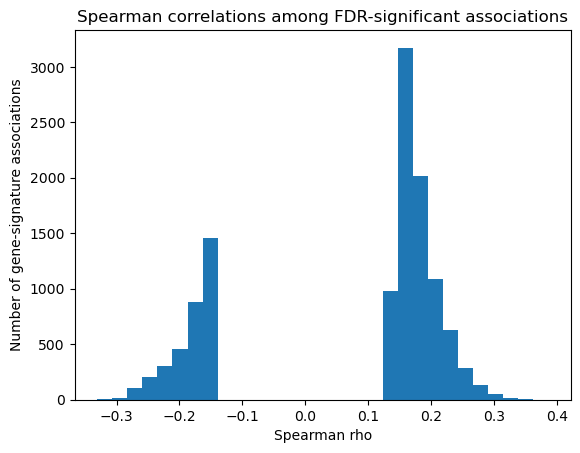

In [41]:
# Plot histogram of spearman correlations of FDR-signficant genes
significant = results[results["FDR"] < 0.05]

plt.hist(significant["rho"], bins=30)
plt.xlabel("Spearman rho")
plt.ylabel("Number of gene-signature associations")
plt.title("Spearman correlations among FDR-significant associations")
plt.show()

In [42]:
# Look to see how many genes reamin with each cutoff
for cutoff in [0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    n = (
        (results["FDR"] < 0.05) &
        (abs(results["rho"]) > cutoff)
    ).sum()

    print(f"|rho| > {cutoff}: {n}")

|rho| > 0.1: 11815
|rho| > 0.2: 2748
|rho| > 0.25: 583
|rho| > 0.3: 47
|rho| > 0.35: 1
|rho| > 0.4: 0
|rho| > 0.5: 0


In [43]:
# Filter for genes that have moderate effect size
significant = results[(results["FDR"] < 0.05) & (abs(results["rho"]) > 0.25)].copy()

print(
    significant
    .groupby("signature")
    .size()
    .sort_values(ascending=False)
)

signature
S4-Signature 1     183
S1-Signature 5     180
max                144
S2-Signature 13     74
S3-Signature 10      1
S5-Signature 2       1
dtype: int64


In [44]:
# Create Ensembl ID -> gene symbol mapping
gene_mapping = (
    sample_counts[next(iter(sample_counts))]
    [["gene_id", "gene_name"]]
    .drop_duplicates("gene_id")
    .set_index("gene_id")["gene_name"]
)

# Filter significant associations for enrichment
enrichr_results = results[
    (results["FDR"] < 0.05) &
    (results["rho"].abs() > 0.25) &
    (results["signature"] != "max")
].copy()

# Add gene names
enrichr_results["gene_name"] = (
    enrichr_results["gene_id"].map(gene_mapping)
)

# Remove any genes that could not be mapped
enrichr_results = enrichr_results.dropna(subset=["gene_name"])

# Inspect number of unique genes per signature
print(
    enrichr_results
    .groupby("signature")["gene_name"]
    .nunique()
    .sort_values(ascending=False)
)

signature
S4-Signature 1     183
S1-Signature 5     180
S2-Signature 13     74
S3-Signature 10      1
S5-Signature 2       1
Name: gene_name, dtype: int64


In [46]:
# Output genes of interest to text files to input into Enrichr
for signature in enrichr_results["signature"].unique():

    signature_results = enrichr_results[
        enrichr_results["signature"] == signature
    ]

    up = signature_results[
        signature_results["rho"] > 0
    ]["gene_name"].drop_duplicates()

    down = signature_results[
        signature_results["rho"] < 0
    ]["gene_name"].drop_duplicates()

    # Make filenames safe
    signature_name = signature.replace("-", "_")

    up.to_csv(
        f"{signature_name}_positive.txt",
        index=False,
        header=False
    )

    down.to_csv(
        f"{signature_name}_negative.txt",
        index=False,
        header=False
    )

    print(
        f"{signature}: {len(up)} positively associated, {len(down)} negatively associated"
    )

S1-Signature 5: 166 positively associated, 14 negatively associated
S2-Signature 13: 72 positively associated, 2 negatively associated
S3-Signature 10: 1 positively associated, 0 negatively associated
S4-Signature 1: 14 positively associated, 169 negatively associated
S5-Signature 2: 0 positively associated, 1 negatively associated
